In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
pd.read_csv("C:\\Users\\Lenovo\\Downloads\\nykaa_dataset.csv")

,Order_ID,Product_Name,Category,Price,Quantity,City,Delivery_Status,Shipping_Mode,Rating,Order_Date
0,1001,Lipstick,makeup,1242.36,8.0,Delhi,Cancelled,Express,2,2023-04-27
1,1002,Shampoo,haircare,639.89,7.0,Delhi,Delivered,Standard,4,2024-11-22
2,1003,Perfume,fragrance,1495.23,2.0,Delhi,Cancelled,Express,2,2024-11-13
3,1004,Face Wash,skincare,1183.12,6.0,Bangalore,Returned,Express,1,2022-07-14
4,1005,Shampoo,haircare,1881.88,6.0,Delhi,Delivered,Standard,4,2023-01-19
...,...,...,...,...,...,...,...,...,...,...
67418,63437,Face Wash,skincare,1646.64,10.0,Mumbai,Delivered,Express,5,2024-11-17
67419,51779,Moisturizer,skincare,1444.59,8.0,Mumbai,Delivered,Standard,4,2022-03-26
67420,12903,Lipstick,makeup,1016.55,NaN,Mumbai,Returned,Standard,5,2024-11-17
67421,14279,Lipstick,makeup,735.00,7.0,Delhi,Returned,Standard,4,2023-05-20


In [10]:
df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\nykaa_dataset.csv")
print(df)

       Order_ID Product_Name   Category    Price  Quantity       City  \
0          1001     Lipstick     makeup  1242.36       8.0      Delhi   
1          1002      Shampoo   haircare   639.89       7.0      Delhi   
2          1003      Perfume  fragrance  1495.23       2.0      Delhi   
3          1004    Face Wash   skincare  1183.12       6.0  Bangalore   
4          1005      Shampoo   haircare  1881.88       6.0      Delhi   
...         ...          ...        ...      ...       ...        ...   
67418     63437    Face Wash   skincare  1646.64      10.0     Mumbai   
67419     51779  Moisturizer   skincare  1444.59       8.0     Mumbai   
67420     12903     Lipstick     makeup  1016.55       NaN     Mumbai   
67421     14279     Lipstick     makeup   735.00       7.0      Delhi   
67422     16218      Shampoo   haircare  1723.80       3.0     Mumbai   

      Delivery_Status Shipping_Mode  Rating  Order_Date  
0           Cancelled       Express       2  2023-04-27  
1      

In [11]:
df.shape

(67423, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67423 entries, 0 to 67422
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         67423 non-null  int64  
 1   Product_Name     67423 non-null  object 
 2   Category         67423 non-null  object 
 3   Price            67423 non-null  float64
 4   Quantity         64119 non-null  float64
 5   City             64058 non-null  object 
 6   Delivery_Status  67423 non-null  object 
 7   Shipping_Mode    67423 non-null  object 
 8   Rating           67423 non-null  int64  
 9   Order_Date       67423 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 5.1+ MB


In [13]:
df.duplicated().sum()

np.int64(2423)

In [14]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

Order_ID              0
Product_Name          0
Category              0
Price                 0
Quantity           3179
City               3253
Delivery_Status       0
Shipping_Mode         0
Rating                0
Order_Date            0
dtype: int64

In [16]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Quantity'].isnull().sum()

np.int64(0)

In [17]:
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['City'].isnull().sum()

np.int64(0)

In [18]:
df.head()

,Order_ID,Product_Name,Category,Price,Quantity,City,Delivery_Status,Shipping_Mode,Rating,Order_Date
0,1001,Lipstick,makeup,1242.36,8.0,Delhi,Cancelled,Express,2,2023-04-27
1,1002,Shampoo,haircare,639.89,7.0,Delhi,Delivered,Standard,4,2024-11-22
2,1003,Perfume,fragrance,1495.23,2.0,Delhi,Cancelled,Express,2,2024-11-13
3,1004,Face Wash,skincare,1183.12,6.0,Bangalore,Returned,Express,1,2022-07-14
4,1005,Shampoo,haircare,1881.88,6.0,Delhi,Delivered,Standard,4,2023-01-19


In [19]:
df.to_excel("nykaa_dataset_cleand.xlsx",index=False)

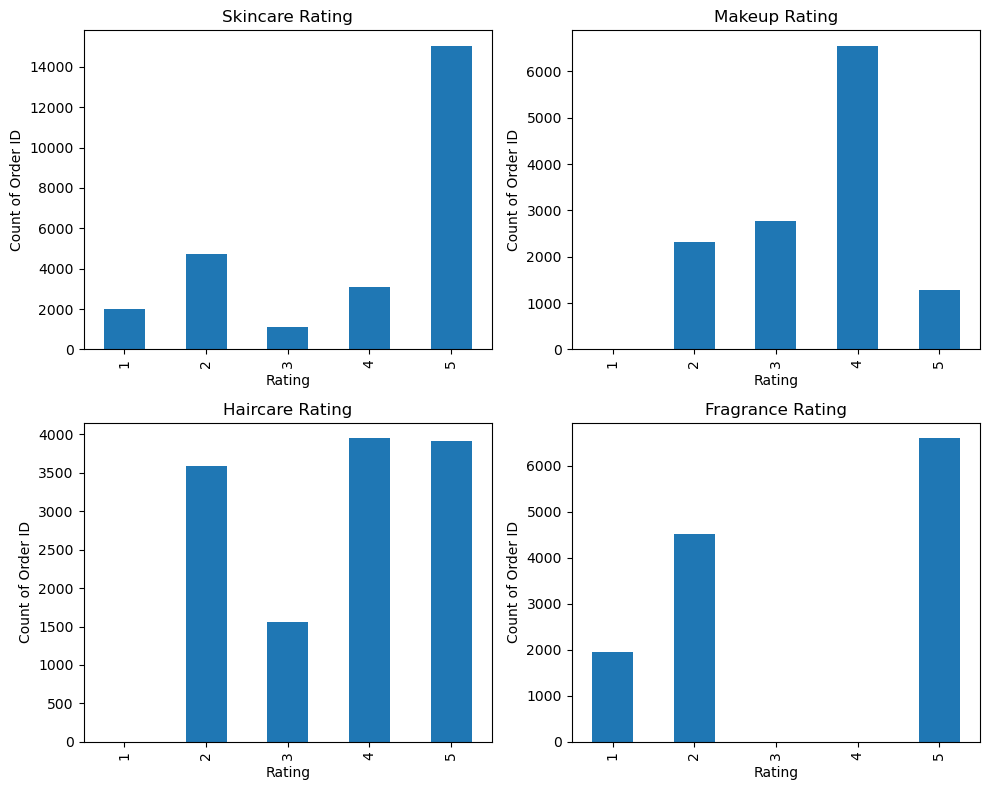

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

pivot = df.pivot_table(
    index='Category',
    columns='Rating',
    values='Order_ID',
    aggfunc='count',
    fill_value=0
)

pivot.loc['skincare'].plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title("Skincare Rating")
axes[0,0].set_ylabel("Count of Order ID")

pivot.loc['makeup'].plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title("Makeup Rating")
axes[0,1].set_ylabel("Count of Order ID")

pivot.loc['haircare'].plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title("Haircare Rating")
axes[1,0].set_ylabel("Count of Order ID")

pivot.loc['fragrance'].plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title("Fragrance Rating")
axes[1,1].set_ylabel("Count of Order ID")

plt.tight_layout()
plt.show()